In [1]:
import pandas as pd
import numpy as np

In [2]:
climate_df = pd.read_csv('datasets/raw_climate_data.csv')

In [3]:
climate_df["Temp_max"] = climate_df["T2M_MAX"]
climate_df["Temp_min"] = climate_df["T2M_MIN"]
climate_df["Rainfall"] = climate_df["PRECTOTCORR"]
climate_df["Humidity"] = climate_df["RH2M"]
climate_df["Soil_pH"] = climate_df["Soil_pH_0_5cm"]

In [4]:
climate_df = climate_df[["County", "Date", "Temp_max", "Temp_min", "Rainfall", "Humidity", "Soil_pH"]]

In [5]:
climate_df.isna().sum()

County      0
Date        0
Temp_max    0
Temp_min    0
Rainfall    0
Humidity    0
Soil_pH     0
dtype: int64

In [8]:
climate_df

,County,Date,Temp_max,Temp_min,Rainfall,Humidity,Soil_pH
0,mombasa,2010-01-01,34.38,23.11,0.45,71.63,6.266667
1,mombasa,2010-01-02,34.48,23.29,2.17,72.44,6.266667
2,mombasa,2010-01-03,32.05,23.79,1.89,75.17,6.266667
3,mombasa,2010-01-04,34.33,23.96,0.39,70.45,6.266667
4,mombasa,2010-01-05,35.09,23.48,1.44,70.43,6.266667
...,...,...,...,...,...,...,...
257508,nairobi,2024-12-27,27.77,14.79,0.14,69.84,6.225000
257509,nairobi,2024-12-28,27.24,14.91,0.07,68.94,6.225000
257510,nairobi,2024-12-29,28.55,13.60,0.01,64.06,6.225000
257511,nairobi,2024-12-30,28.04,13.93,0.05,65.32,6.225000


In [9]:
crop_prices_df = pd.read_csv('datasets/raw_crop_data.csv')

In [10]:
crop_prices_df["County"] = crop_prices_df["County"].str.strip().str.lower()

In [11]:
crop_prices_df["Wholesale"].isna().sum()
crop_prices_df["Wholesale"] = crop_prices_df["Wholesale"].fillna(crop_prices_df["Wholesale"].mean())
crop_prices_df["Wholesale"].isna().sum()

np.int64(0)

In [12]:
crop_prices_df["Retail"].isna().sum()
crop_prices_df["Retail"] = crop_prices_df["Retail"].fillna(crop_prices_df["Retail"].mean())
crop_prices_df["Retail"].isna().sum()

np.int64(0)

In [13]:
crop_prices_df["Crop"] = crop_prices_df["Commodity"]

In [14]:
crop_prices_df = crop_prices_df[["County", "Crop", "Wholesale", "Retail","Date"]] 

In [15]:
crop_prices_df

,County,Crop,Wholesale,Retail,Date
0,kwale,Tomatoes,80.000000,100.000000,2026-03-03
1,trans-nzoia,Tomatoes,60.000000,80.000000,2026-03-03
2,taita-taveta,Tomatoes,65.192076,60.000000,2026-03-03
3,taita-taveta,Tomatoes,60.000000,99.084886,2026-03-03
4,taita-taveta,Tomatoes,60.000000,99.084886,2026-03-03
...,...,...,...,...,...
18186,bungoma,Dry Onions,90.000000,100.000000,2024-06-21
18187,kitui,Dry Onions,130.000000,180.000000,2024-06-21
18188,kilifi,Dry Onions,233.330000,200.000000,2024-06-21
18189,trans-nzoia,Dry Onions,150.000000,200.000000,2024-06-21


In [48]:
merged_df = pd.merge(
    crop_prices_df,
    climate_df,
    on=["County", "Date"],
    how="inner"
)

In [49]:
merged_df

,County,Crop,Wholesale,Retail,Date,Temp_max,Temp_min,Rainfall,Humidity,Soil_pH
0,nairobi,Tomatoes,65.192076,70.0,2024-11-18,27.68,16.09,0.59,73.36,6.225
1,nairobi,Tomatoes,60.000000,80.0,2024-11-11,24.60,16.82,3.84,77.97,6.225
2,nairobi,Tomatoes,65.192076,120.0,2024-11-08,28.66,16.12,1.79,65.83,6.225
3,nairobi,Tomatoes,65.192076,70.0,2024-11-06,28.95,16.27,4.48,70.78,6.225
4,nairobi,Tomatoes,65.192076,80.0,2024-10-16,31.35,15.55,0.08,51.22,6.225
...,...,...,...,...,...,...,...,...,...,...
7672,kirinyaga,Dry Onions,80.000000,130.0,2024-06-21,24.20,14.30,1.00,80.98,5.900
7673,bungoma,Dry Onions,90.000000,100.0,2024-06-21,27.31,17.20,2.70,73.73,5.450
7674,kitui,Dry Onions,130.000000,180.0,2024-06-21,29.70,17.76,0.43,69.69,6.400
7675,kilifi,Dry Onions,233.330000,200.0,2024-06-21,28.07,25.10,1.65,76.14,6.300


In [50]:
merged_df.isna().sum()

County       0
Crop         0
Wholesale    0
Retail       0
Date         0
Temp_max     0
Temp_min     0
Rainfall     0
Humidity     0
Soil_pH      0
dtype: int64

In [51]:
# Date decomposition
import pandas as pd

# Ensure your Date column is in the correct datetime format
merged_df['Date'] = pd.to_datetime(merged_df['Date'])

# Extract Year, Month, and Day
merged_df['Year'] = merged_df['Date'].dt.year
merged_df['Month'] = merged_df['Date'].dt.month
merged_df['Day'] = merged_df['Date'].dt.day

# Optional: Extract the Quarter (useful for seasonal financial trends)
merged_df['Quarter'] = merged_df['Date'].dt.quarter

In [52]:
merged_df

,County,Crop,Wholesale,Retail,Date,Temp_max,Temp_min,Rainfall,Humidity,Soil_pH,Year,Month,Day,Quarter
0,nairobi,Tomatoes,65.192076,70.0,2024-11-18,27.68,16.09,0.59,73.36,6.225,2024,11,18,4
1,nairobi,Tomatoes,60.000000,80.0,2024-11-11,24.60,16.82,3.84,77.97,6.225,2024,11,11,4
2,nairobi,Tomatoes,65.192076,120.0,2024-11-08,28.66,16.12,1.79,65.83,6.225,2024,11,8,4
3,nairobi,Tomatoes,65.192076,70.0,2024-11-06,28.95,16.27,4.48,70.78,6.225,2024,11,6,4
4,nairobi,Tomatoes,65.192076,80.0,2024-10-16,31.35,15.55,0.08,51.22,6.225,2024,10,16,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7672,kirinyaga,Dry Onions,80.000000,130.0,2024-06-21,24.20,14.30,1.00,80.98,5.900,2024,6,21,2
7673,bungoma,Dry Onions,90.000000,100.0,2024-06-21,27.31,17.20,2.70,73.73,5.450,2024,6,21,2
7674,kitui,Dry Onions,130.000000,180.0,2024-06-21,29.70,17.76,0.43,69.69,6.400,2024,6,21,2
7675,kilifi,Dry Onions,233.330000,200.0,2024-06-21,28.07,25.10,1.65,76.14,6.300,2024,6,21,2


In [53]:
# # price spread - profitability analysis
# # Calculate the absolute difference
# merged_df['Price_Spread'] = merged_df['Retail'] - merged_df['Wholesale']

# # Calculate the Percentage Margin (often more useful for comparison across different crops)
# # Formula: (Retail - Wholesale) / Wholesale
# merged_df['Price_Margin_Pct'] = (merged_df['Price_Spread'] / merged_df['Wholesale']) * 100

# Calculate the average ratio from 'healthy' tomato rows
healthy_tomatoes = merged_df[(merged_df['Crop'] == 'Tomatoes') & (merged_df['Wholesale'] < merged_df['Retail'])]
avg_ratio = (healthy_tomatoes['Wholesale'] / healthy_tomatoes['Retail']).mean()

# Apply this ratio to the 'broken' rows
mask = (merged_df['Crop'] == 'Tomatoes') & (merged_df['Wholesale'] >= merged_df['Retail'])
merged_df.loc[mask, 'Wholesale'] = merged_df.loc[mask, 'Retail'] * avg_ratio

# Recalculate your features
merged_df['Price_Spread'] = merged_df['Retail'] - merged_df['Wholesale']
merged_df['Price_Margin_Pct'] = (merged_df['Price_Spread'] / merged_df['Wholesale']) * 100

In [54]:
merged_df

,County,Crop,Wholesale,Retail,Date,Temp_max,Temp_min,Rainfall,Humidity,Soil_pH,Year,Month,Day,Quarter,Price_Spread,Price_Margin_Pct
0,nairobi,Tomatoes,65.192076,70.0,2024-11-18,27.68,16.09,0.59,73.36,6.225,2024,11,18,4,4.807924,7.375013
1,nairobi,Tomatoes,60.000000,80.0,2024-11-11,24.60,16.82,3.84,77.97,6.225,2024,11,11,4,20.000000,33.333333
2,nairobi,Tomatoes,65.192076,120.0,2024-11-08,28.66,16.12,1.79,65.83,6.225,2024,11,8,4,54.807924,84.071450
3,nairobi,Tomatoes,65.192076,70.0,2024-11-06,28.95,16.27,4.48,70.78,6.225,2024,11,6,4,4.807924,7.375013
4,nairobi,Tomatoes,65.192076,80.0,2024-10-16,31.35,15.55,0.08,51.22,6.225,2024,10,16,4,14.807924,22.714300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7672,kirinyaga,Dry Onions,80.000000,130.0,2024-06-21,24.20,14.30,1.00,80.98,5.900,2024,6,21,2,50.000000,62.500000
7673,bungoma,Dry Onions,90.000000,100.0,2024-06-21,27.31,17.20,2.70,73.73,5.450,2024,6,21,2,10.000000,11.111111
7674,kitui,Dry Onions,130.000000,180.0,2024-06-21,29.70,17.76,0.43,69.69,6.400,2024,6,21,2,50.000000,38.461538
7675,kilifi,Dry Onions,233.330000,200.0,2024-06-21,28.07,25.10,1.65,76.14,6.300,2024,6,21,2,-33.330000,-14.284490


In [55]:
from sklearn.preprocessing import LabelEncoder

# Initialize encoders
county_encoder = LabelEncoder()
crop_encoder = LabelEncoder()

# Fit and transform the columns
merged_df['County_Encoded'] = county_encoder.fit_transform(merged_df['County'])
merged_df['Crop_Encoded'] = crop_encoder.fit_transform(merged_df['Crop'])

# Create mapping dictionaries for later use (Decoding)
county_mapping = dict(zip(county_encoder.classes_, county_encoder.transform(county_encoder.classes_)))
crop_mapping = dict(zip(crop_encoder.classes_, crop_encoder.transform(crop_encoder.classes_)))

print("Crop Mapping:", crop_mapping)

Crop Mapping: {'Coffee': np.int64(0), 'Dry Maize': np.int64(1), 'Dry Onions': np.int64(2), 'Kales/Sukuma Wiki': np.int64(3), 'Rice': np.int64(4), 'Tea': np.int64(5), 'Tomatoes': np.int64(6), 'Wheat': np.int64(7)}


In [56]:
merged_df

,County,Crop,Wholesale,Retail,Date,Temp_max,Temp_min,Rainfall,Humidity,Soil_pH,Year,Month,Day,Quarter,Price_Spread,Price_Margin_Pct,County_Encoded,Crop_Encoded
0,nairobi,Tomatoes,65.192076,70.0,2024-11-18,27.68,16.09,0.59,73.36,6.225,2024,11,18,4,4.807924,7.375013,26,6
1,nairobi,Tomatoes,60.000000,80.0,2024-11-11,24.60,16.82,3.84,77.97,6.225,2024,11,11,4,20.000000,33.333333,26,6
2,nairobi,Tomatoes,65.192076,120.0,2024-11-08,28.66,16.12,1.79,65.83,6.225,2024,11,8,4,54.807924,84.071450,26,6
3,nairobi,Tomatoes,65.192076,70.0,2024-11-06,28.95,16.27,4.48,70.78,6.225,2024,11,6,4,4.807924,7.375013,26,6
4,nairobi,Tomatoes,65.192076,80.0,2024-10-16,31.35,15.55,0.08,51.22,6.225,2024,10,16,4,14.807924,22.714300,26,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7672,kirinyaga,Dry Onions,80.000000,130.0,2024-06-21,24.20,14.30,1.00,80.98,5.900,2024,6,21,2,50.000000,62.500000,13,2
7673,bungoma,Dry Onions,90.000000,100.0,2024-06-21,27.31,17.20,2.70,73.73,5.450,2024,6,21,2,10.000000,11.111111,2,2
7674,kitui,Dry Onions,130.000000,180.0,2024-06-21,29.70,17.76,0.43,69.69,6.400,2024,6,21,2,50.000000,38.461538,16,2
7675,kilifi,Dry Onions,233.330000,200.0,2024-06-21,28.07,25.10,1.65,76.14,6.300,2024,6,21,2,-33.330000,-14.284490,12,2


In [57]:
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

import pandas as pd

# List of the 7 original base columns you already have
# ['Temp_max', 'Temp_min', 'Rainfall', 'Humidity', 'Soil_pH', 'County_Encoded', 'Month']

# 1. Calculate Temperature Range (captures daily variance)
merged_df['Temp_Range'] = merged_df['Temp_max'] - merged_df['Temp_min']

# 2. Calculate Rainfall per Degree (captures evaporation/efficiency)
# We add +1 to Temp_max to avoid division by zero errors
merged_df['Rain_per_Temp'] = merged_df['Rainfall'] / (merged_df['Temp_max'] + 1)

# Define the final 9-feature list in a specific order
features = [
    'Temp_max', 
    'Temp_min', 
    'Temp_Range', 
    'Rainfall', 
    'Humidity', 
    'Soil_pH', 
    'County_Encoded', 
    'Month', 
    'Rain_per_Temp'
]

# Create your Feature matrix X
# X = merged_df[features]
# y = merged_df['Crop_Encoded']

# print("Features successfully generated. Current shape:", X.shape)
# print(X.head())

# --- STEP 1: PREPARE DATA ---
# Ensure merged_df has the 9 features (Temp_Range, Rain_per_Temp, etc.)
X_suit = merged_df[features] 
y_suit = merged_df['Crop_Encoded']

# Split and Scale
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_suit, y_suit, test_size=0.2, stratify=y_suit, random_state=42)
scaler = StandardScaler()
X_train_s_scaled = scaler.fit_transform(X_train_s)
X_test_s_scaled = scaler.transform(X_test_s)

# SMOTE
sm = SMOTE(k_neighbors=1, random_state=42)
X_res_s, y_res_s = sm.fit_resample(X_train_s_scaled, y_train_s)

# --- STEP 2: TRAIN XGBOOST ---
xgb_suit_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    objective='multi:softprob',
    random_state=42
)
xgb_suit_model.fit(X_res_s, y_res_s)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [58]:
# evaulate the model
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# 1. Get Predictions
y_pred = xgb_suit_model.predict(X_test_s_scaled)
y_probs = xgb_suit_model.predict_proba(X_test_s_scaled)

# 2. Basic Metrics
accuracy = accuracy_score(y_test_s, y_pred)
# Calculate ROC-AUC for multi-class (using One-vs-Rest strategy)
auc_score = roc_auc_score(y_test_s, y_probs, multi_class='ovr')

print(f"--- XGBoost Suitability Evaluation ---")
print(f"Overall Accuracy: {accuracy * 100:.2f}%")
print(f"ROC-AUC Score: {auc_score:.4f}")
print("\n--- Detailed Report per Crop ---")
print(classification_report(y_test_s, y_pred))

--- XGBoost Suitability Evaluation ---
Overall Accuracy: 36.33%
ROC-AUC Score: 0.7789

--- Detailed Report per Crop ---
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.12      0.15      0.13       182
           2       0.05      0.04      0.04       220
           3       0.30      0.25      0.28       278
           4       0.27      0.37      0.31       224
           5       0.92      0.74      0.82        31
           6       0.12      0.14      0.13       203
           7       0.93      0.80      0.86       396

    accuracy                           0.36      1536
   macro avg       0.40      0.37      0.38      1536
weighted avg       0.39      0.36      0.37      1536



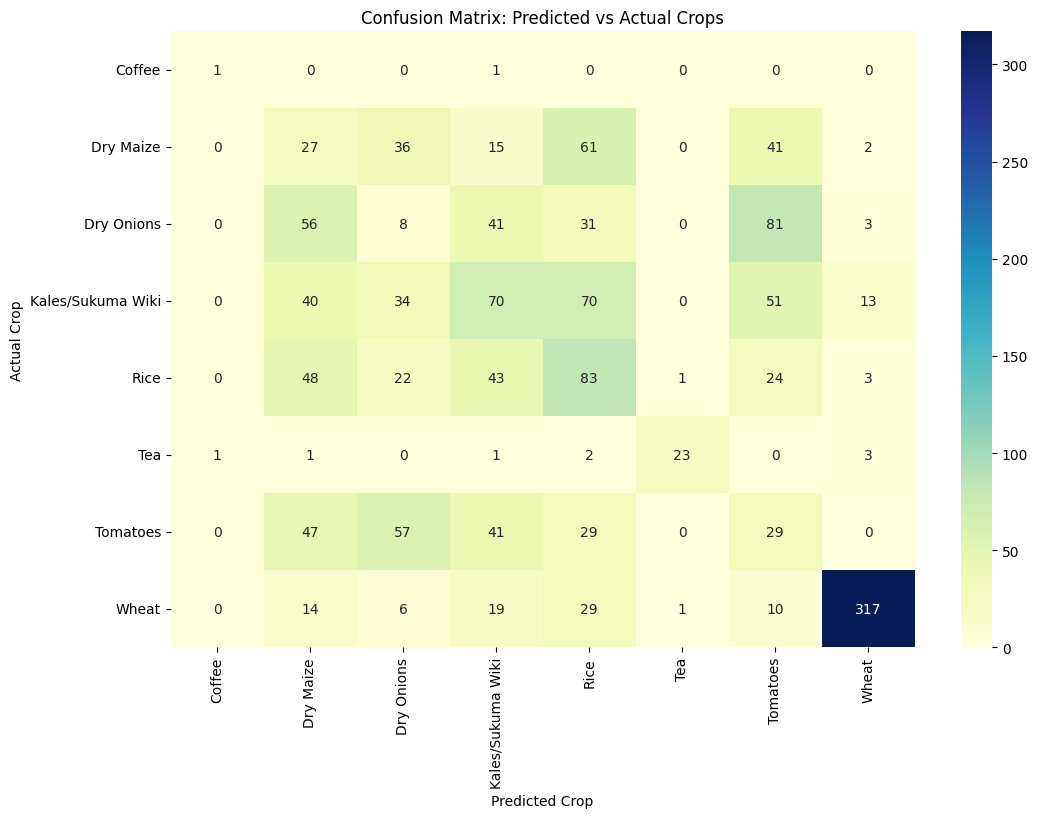

In [59]:
# plotting
# 3. Confusion Matrix Visualization
plt.figure(figsize=(12, 8))
cm = confusion_matrix(y_test_s, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', 
            xticklabels=crop_mapping.keys(), 
            yticklabels=crop_mapping.keys())
plt.title('Confusion Matrix: Predicted vs Actual Crops')
plt.xlabel('Predicted Crop')
plt.ylabel('Actual Crop')
plt.show()

<Figure size 1000x600 with 0 Axes>

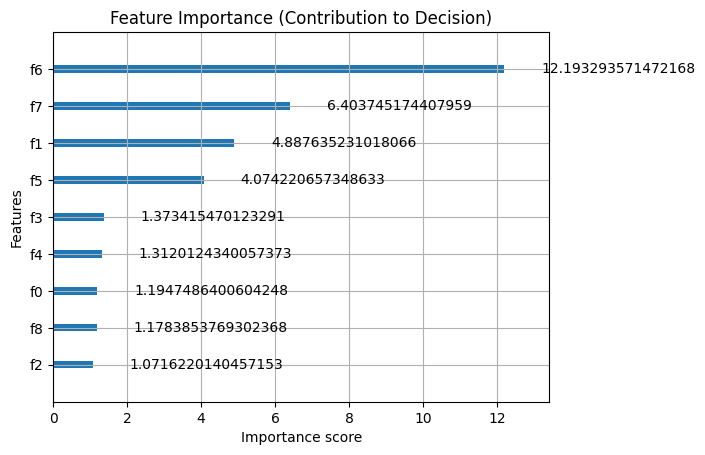

In [60]:
# Plotting Feature Importance
plt.figure(figsize=(10, 6))
# 'gain' shows the average reduction in loss brought by a feature
xgb.plot_importance(xgb_suit_model, importance_type='gain', title='Feature Importance (Contribution to Decision)')
plt.show()

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Define Features and Target
price_features = ['Crop_Encoded', 'County_Encoded', 'Month', 'Year', 'Rainfall']
X_p = merged_df[price_features].values
y_p = merged_df['Wholesale'].values

# 2. Chronological Split (80% Train, 20% Test)
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_p, y_p, test_size=0.2, shuffle=False
)

# 3. Reshape for LSTM (Samples, Time_Steps, Features)
X_train_p_reshaped = X_train_p.reshape((X_train_p.shape[0], 1, X_train_p.shape[1]))
X_test_p_reshaped = X_test_p.reshape((X_test_p.shape[0], 1, X_test_p.shape[1]))

# 4. Train the model (Using your architecture)
history = lstm_model.fit(
    X_train_p_reshaped, y_train_p, 
    epochs=50, 
    batch_size=32, 
    validation_data=(X_test_p_reshaped, y_test_p),
    verbose=0
)

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
--- LSTM Price Model Evaluation ---
Mean Absolute Error: KES 34.63
R-squared Score: -0.0023
Model Accuracy: 55.23%


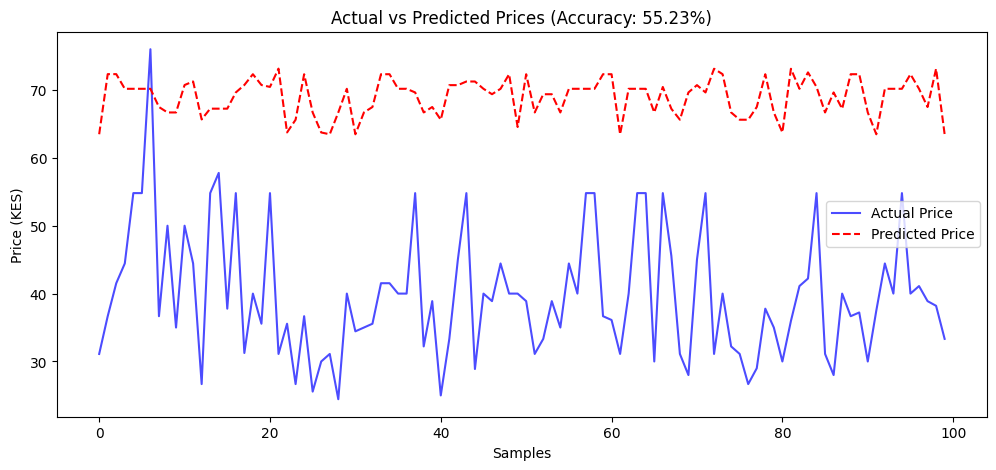

In [67]:
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error

# 1. Make Predictions
price_preds = lstm_model.predict(X_test_p_reshaped)

# 2. Calculate Metrics
mae = mean_absolute_error(y_test_p, price_preds)
r2 = r2_score(y_test_p, price_preds)

# 3. Calculate "Accuracy Percentage"
# MAPE gives the percentage of error. Accuracy is 100% minus that error.
mape = mean_absolute_percentage_error(y_test_p, price_preds)
accuracy_pct = (1 - mape) * 100

print(f"--- LSTM Price Model Evaluation ---")
print(f"Mean Absolute Error: KES {mae:.2f}")
print(f"R-squared Score: {r2:.4f}")
print(f"Model Accuracy: {accuracy_pct:.2f}%") # This is what you need!

# 4. Visual Comparison
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(y_test_p[:100], label='Actual Price', color='blue', alpha=0.7)
plt.plot(price_preds[:100], label='Predicted Price', color='red', linestyle='--')
plt.title(f'Actual vs Predicted Prices (Accuracy: {accuracy_pct:.2f}%)')
plt.xlabel('Samples')
plt.ylabel('Price (KES)')
plt.legend()
plt.show()

In [71]:
# combine
def recommend_smart_crop(temp_max, temp_min, rainfall, humidity, soil_ph, county_name):
    county_enc = county_mapping[county_name]
    month, year = 5, 2026
    
    # 1. Feature Engineering
    temp_range = temp_max - temp_min
    rain_per_temp = rainfall / (temp_max + 1)
    
    # 2. Suitability Prediction (XGBoost)
    input_df = pd.DataFrame([[temp_max, temp_min, temp_range, rainfall, humidity, 
                               soil_ph, county_enc, month, rain_per_temp]], columns=features)
    input_scaled = scaler.transform(input_df)
    suit_probs = xgb_suit_model.predict_proba(input_scaled)[0]
    
    results = []
    
    # 3. Price Prediction (LSTM)
    for crop_name, crop_id in crop_mapping.items():
        # Shape: (1 sample, 1 time step, 5 features)
        price_input = np.array([[crop_id, county_enc, month, year, rainfall]]).reshape((1, 1, 5))
        pred_price = lstm_model.predict(price_input, verbose=0)[0][0]
        
        prob = suit_probs[crop_id]
        
        # Recommendation Score = Bio-Suitability * Economic Value
        # We also filter out crops with < 10% suitability to protect the farmer
        if prob > 0.10:
            results.append({
                'Crop': crop_name,
                'Suitability': f"{prob*100:.1f}%",
                'Predicted_Price': round(float(pred_price), 2),
                'Final_Score': prob * pred_price
            })
            
    return sorted(results, key=lambda x: x['Final_Score'], reverse=True)

# Test Run
print(recommend_smart_crop(27, 19, 950, 70, 6.0, 'kilifi'))

[{'Crop': 'Tea', 'Suitability': '26.1%', 'Predicted_Price': 120.38, 'Final_Score': np.float32(31.469648)}, {'Crop': 'Wheat', 'Suitability': '22.7%', 'Predicted_Price': 136.35, 'Final_Score': np.float32(30.997797)}, {'Crop': 'Kales/Sukuma Wiki', 'Suitability': '25.8%', 'Predicted_Price': 110.91, 'Final_Score': np.float32(28.612686)}, {'Crop': 'Rice', 'Suitability': '24.9%', 'Predicted_Price': 114.51, 'Final_Score': np.float32(28.500013)}]
